#Estimation of Obesity Levels Based On Eating Habits and Physical Condition Data Visualization


The objective of this analysis is to explore the relationship between lifestyle behaviors and obesity levels using the dataset.  
We aim to identify key patterns and insights that can help explain factors contributing to obesity.

In [ ]:
import pandas as pd

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

The dataset contains demographic and behavioral information such as:
- Gender, Age
- Height and Weight
- Eating habits (e.g., fast food consumption)
- Physical activity level (FAF)
- Water intake (CH2O)
- Obesity level classification (NObeyesdad)

The target variable is **NObeyesdad**, which represents different levels of obesity.


###  Distribution of Obesity Levels
This visualization shows the number of individuals in each obesity category.

**Insight:**
- The dataset contains multiple obesity categories, including normal weight, overweight, and various obesity levels.
- If the distribution is uneven, it may indicate a class imbalance, which could affect further analysis or modeling.

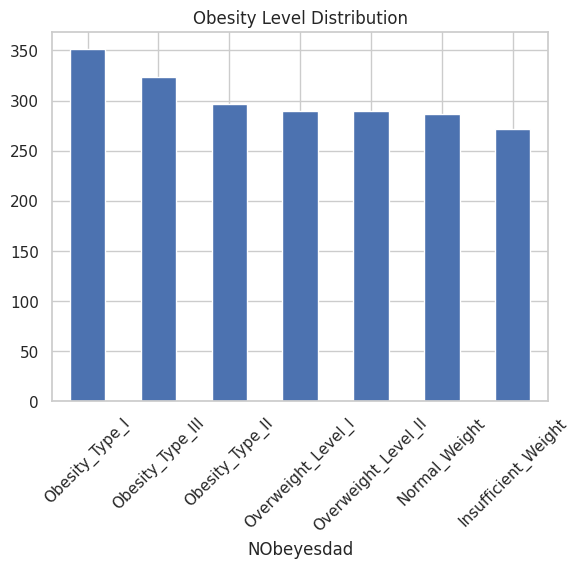

In [ ]:
import matplotlib.pyplot as plt


df['NObeyesdad'].value_counts().plot(kind='bar')
plt.title('Obesity Level Distribution')
plt.xticks(rotation=45)
plt.show()

### Gender vs Obesity Level
This chart compares obesity levels across genders.

**Insight:**
- Differences between male and female distributions may suggest gender-related behavioral or biological factors.
- If one gender shows consistently higher obesity levels, this could indicate potential bias or real-world trends.

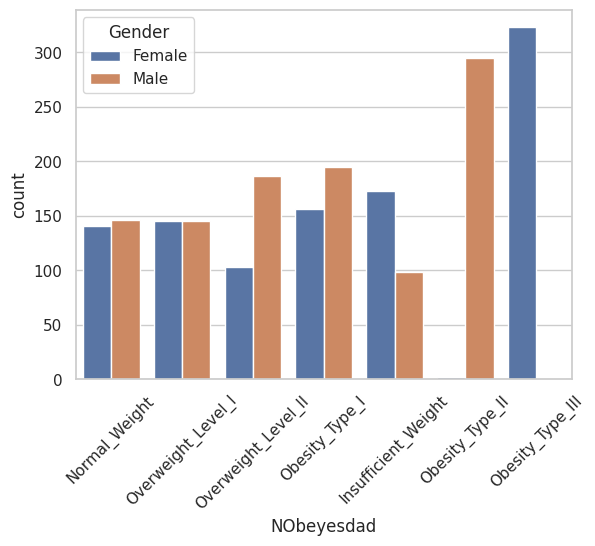

In [ ]:
import seaborn as sns

sns.countplot(data=df, x='NObeyesdad', hue='Gender')
plt.xticks(rotation=45)
plt.show()

Height vs Weight (Correlation Analysis)
A scatter plot is used to visualize the relationship between height and weight, colored by obesity level.

**Insight:**
- Clear clustering can be observed, where individuals with higher weight tend to fall into higher obesity categories.
- Height has less variation compared to weight, suggesting weight is a stronger determinant of obesity classification.

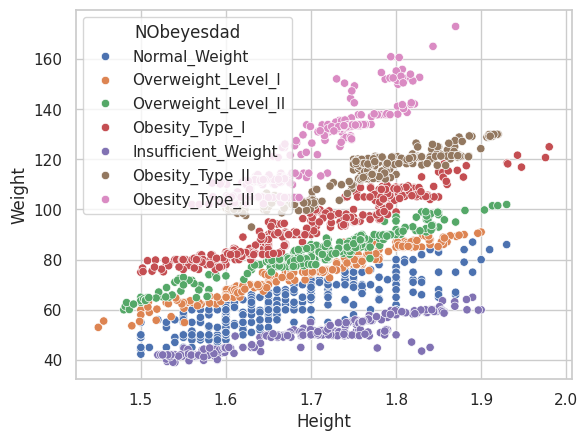

In [ ]:
sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad')
plt.show()

Physical Activity vs Obesity
A boxplot is used to analyze the relationship between physical activity frequency (FAF) and obesity level.

**Insight:**
- Individuals with lower physical activity levels tend to have higher obesity levels.
- This suggests that exercise plays a significant role in maintaining a healthy weight.

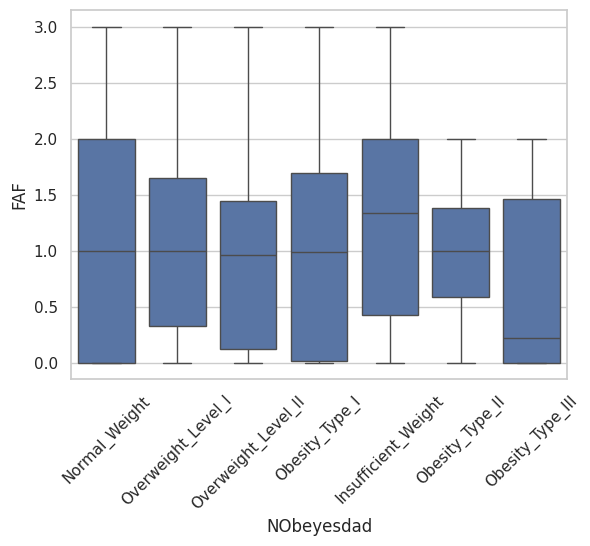

In [ ]:
sns.boxplot(data=df, x='NObeyesdad', y='FAF')
plt.xticks(rotation=45)
plt.show()

### Fast Food Consumption vs Obesity
This visualization compares fast food consumption (FAVC) with obesity levels.

**Insight:**
- Individuals who frequently consume fast food show a higher tendency toward overweight and obesity.
- This supports the hypothesis that unhealthy eating habits contribute to obesity.


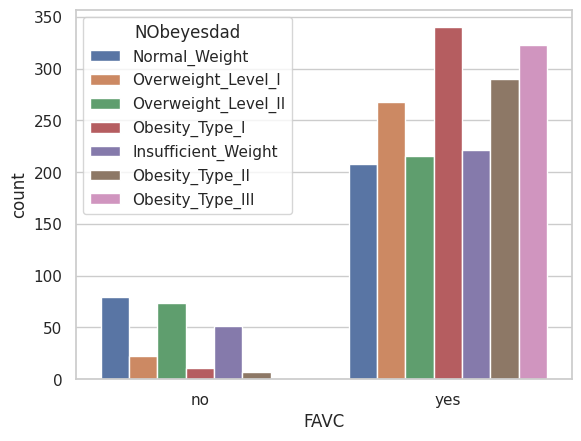

In [ ]:
sns.countplot(data=df, x='FAVC', hue='NObeyesdad')
plt.show()

### Correlation Heatmap
A heatmap is used to identify relationships between numerical variables.

**Insight:**
- Weight shows strong correlation with obesity level.
- Lifestyle factors such as physical activity (FAF) and water intake (CH2O) may show weaker but meaningful relationships.
- These variables could be important for predicting or managing obesity.


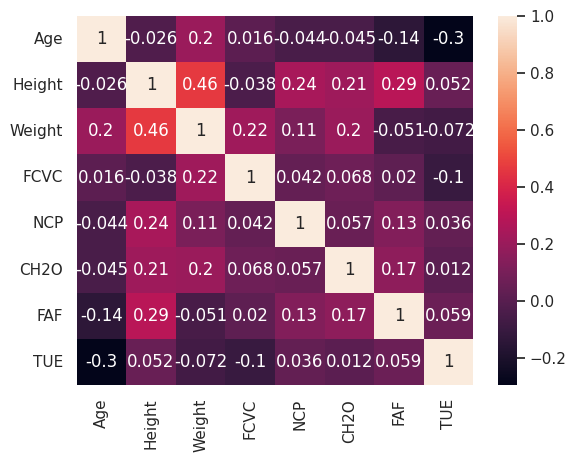

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

#Vegetable Consumption

In [ ]:
df['VegGroup'] = pd.cut(df['FCVC'],
                       bins=[0, 1.5, 2.5, 3],
                       labels=['Low Veg', 'Medium Veg', 'High Veg'])

/tmp/ipykernel_18810/4056506994.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  veg_age = df.groupby('AgeGroup')['VegGroup'].value_counts(normalize=True).unstack()


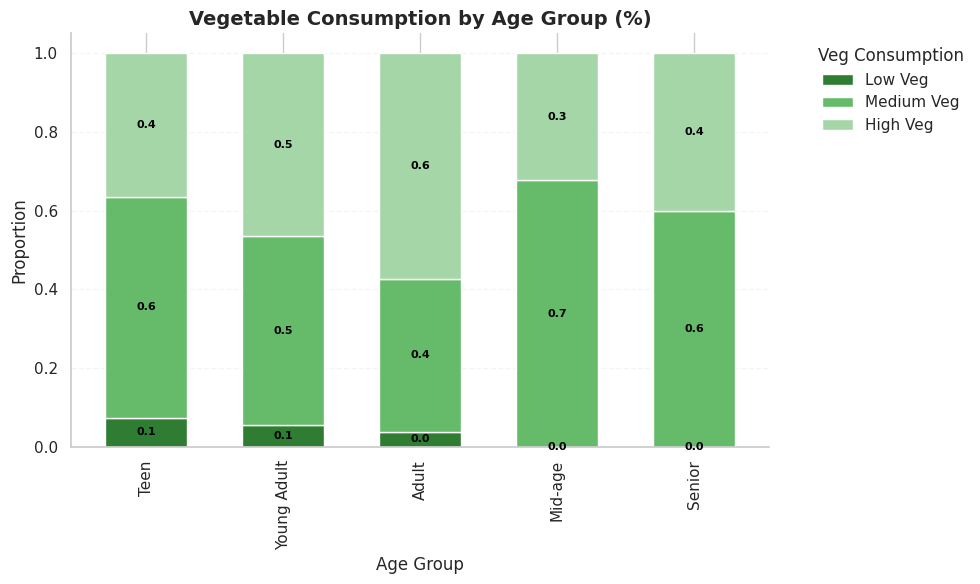

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

veg_age = df.groupby('AgeGroup')['VegGroup'].value_counts(normalize=True).unstack()

sns.set_style("whitegrid")

# ===== custom veggie palette (อ่านง่ายกว่า Greens colormap) =====
veg_colors = [
    '#2e7d32',  # dark green (high intake)
    '#66bb6a',  # medium green
    '#a5d6a7',  # light green
    '#c8e6c9'   # very light green
]

fig, ax = plt.subplots(figsize=(10,6))

veg_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=veg_colors[:veg_age.shape[1]],  # 👈 fix palette control
    ax=ax,
    width=0.6
)

# ===== title =====
plt.title('Vegetable Consumption by Age Group (%)',
          fontsize=14, weight='bold')

plt.ylabel('Proportion')
plt.xlabel('Age Group')

# ===== legend =====
plt.legend(title='Veg Consumption',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False)

# ===== label (make readable) =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        label_type='center',
        fontsize=8,
        color='black',   # 👈 สำคัญ: จากเดิมอาจอ่านยากบนเขียวเข้ม
        weight='bold'
    )

# ===== clean style =====
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()


/tmp/ipykernel_18810/1722710883.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df,


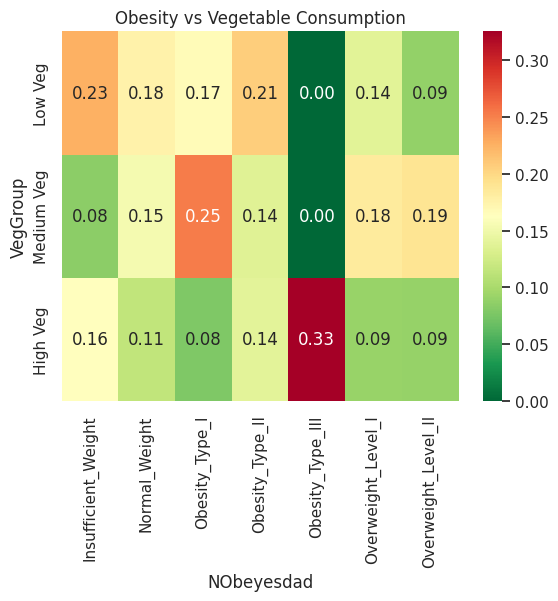

In [ ]:
pivot = pd.pivot_table(df,
                       values='Age',
                       index='VegGroup',
                       columns='NObeyesdad',
                       aggfunc='count',
                       fill_value=0)

# normalize
pivot = pivot.div(pivot.sum(axis=1), axis=0)

sns.heatmap(pivot,
            annot=True,
            cmap='RdYlGn_r',
            fmt='.2f')

plt.title('Obesity vs Vegetable Consumption')
plt.show()

#Lifestyle Region

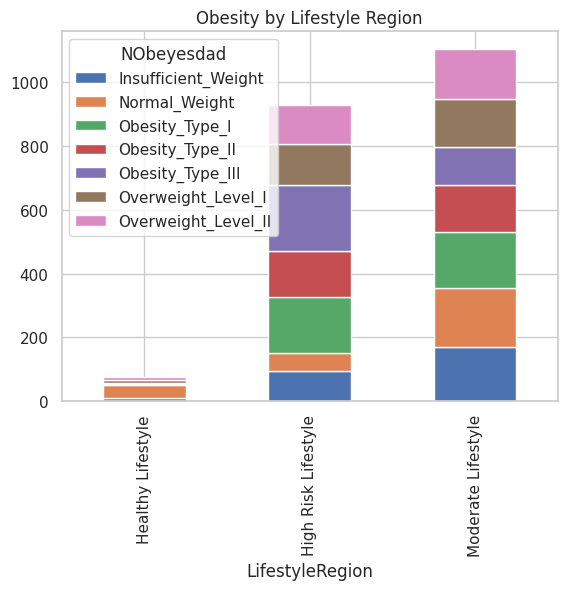

In [ ]:
def lifestyle_region(row):
    if row['FAF'] >= 2 and row['FAVC'] == 'no':
        return 'Healthy Lifestyle'
    elif row['FAF'] < 1 and row['FAVC'] == 'yes':
        return 'High Risk Lifestyle'
    else:
        return 'Moderate Lifestyle'

df['LifestyleRegion'] = df.apply(lifestyle_region, axis=1)


region_group = df.groupby('LifestyleRegion')['NObeyesdad'].value_counts().unstack()

region_group.plot(kind='bar', stacked=True, title='Obesity by Lifestyle Region')
plt.show()

#Population Region

In [ ]:
obesity_rate = (df['NObeyesdad'].str.contains('Obesity').mean()) * 100

In [ ]:
import pandas as pd

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

<Figure size 1500x800 with 0 Axes>

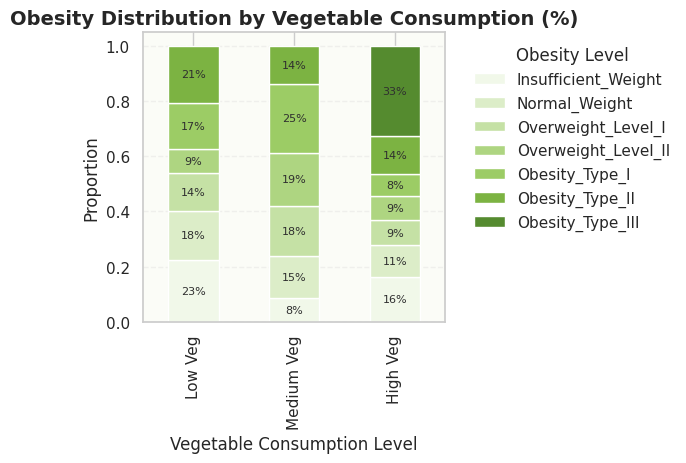

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Prepare data =====
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0, 18, 25, 35, 50, 100],
                       labels=['Teen', 'Young Adult', 'Adult', 'Mid-age', 'Senior'])

df['VegGroup'] = pd.cut(df['FCVC'],
                       bins=[0, 1.5, 2.5, 3],
                       labels=['Low Veg', 'Medium Veg', 'High Veg'])

# ===== Pivot =====
pivot = pd.crosstab(df['VegGroup'],
                    df['NObeyesdad'],
                    normalize='index')

order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

pivot = pivot[order]

# ===== MATCHA / VEGETABLE COLOR PALETTE =====
colors = [
    '#f1f8e9',  # very light green (background tone)
    '#dcedc8',  # pale matcha
    '#c5e1a5',  # light green
    '#aed581',  # soft green
    '#9ccc65',  # matcha green
    '#7cb342',  # deep leaf green
    '#558b2f'   # dark forest green
]

# ===== Plot =====
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15,8))

ax = pivot.plot(
    kind='bar',
    stacked=True,
    color=colors
)

# ===== Title =====
plt.title('Obesity Distribution by Vegetable Consumption (%)',
          fontsize=14, weight='bold')

plt.xlabel('Vegetable Consumption Level')
plt.ylabel('Proportion')

# ===== Legend =====
plt.legend(title='Obesity Level',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False)

# ===== Add % labels =====
for i in range(len(pivot)):
    cumulative = 0
    for j in range(len(pivot.columns)):
        value = pivot.iloc[i, j]

        if value > 0.05:
            plt.text(
                i,
                cumulative + value/2,
                f'{value:.0%}',
                ha='center',
                va='center',
                fontsize=8,
                color='#2f2f2f'
            )

        cumulative += value

# ===== Soft aesthetic =====
plt.gca().set_facecolor('#fbfcf7')  # warm off-white (matcha vibe)
plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

veg_age = df.groupby('AgeGroup')['VegGroup'].value_counts(normalize=True).unstack()

sns.set_style("whitegrid")

# ===== custom veggie palette (อ่านง่ายกว่า Greens colormap) =====
veg_colors = [
    '#2e7d32',  # dark green (high intake)
    '#66bb6a',  # medium green
    '#a5d6a7',  # light green
    '#c8e6c9'   # very light green
]

fig, ax = plt.subplots(figsize=(10,6))

veg_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=veg_colors[:veg_age.shape[1]],  # 👈 fix palette control
    ax=ax,
    width=0.6
)

# ===== title =====
plt.title('Vegetable Consumption by Age Group (%)',
          fontsize=14, weight='bold')

plt.ylabel('Proportion')
plt.xlabel('Age Group')

# ===== legend =====
plt.legend(title='Veg Consumption',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False)

# ===== label (make readable) =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        label_type='center',
        fontsize=8,
        color='black',   # 👈 สำคัญ: จากเดิมอาจอ่านยากบนเขียวเข้ม
        weight='bold'
    )

# ===== clean style =====
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()


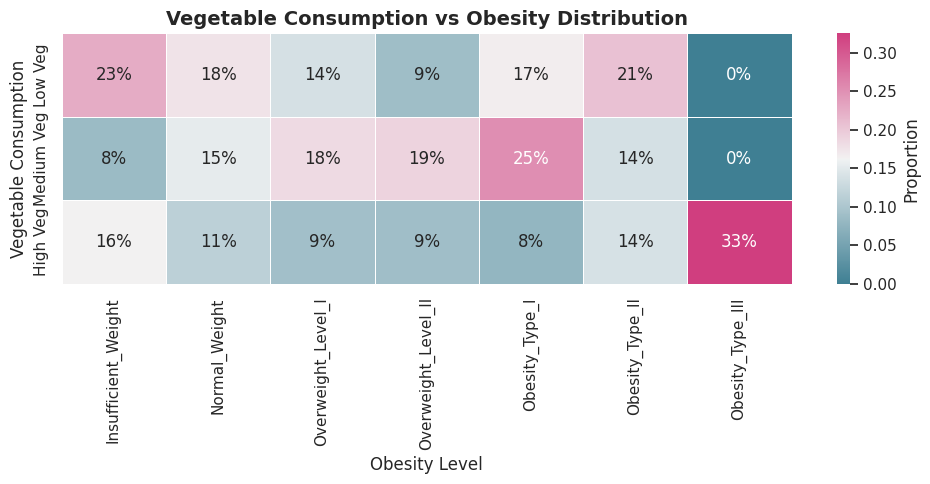

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Data Prep =====
df['VegGroup'] = pd.cut(df['FCVC'],
                       bins=[0, 1.5, 2.5, 3],
                       labels=['Low Veg', 'Medium Veg', 'High Veg'])

# ===== Pivot (% ต่อแถว) =====
pivot = pd.crosstab(df['VegGroup'],
                    df['NObeyesdad'],
                    normalize='index')

# เรียงลำดับ obesity
order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

pivot = pivot[order]

# ===== Plot =====
plt.figure(figsize=(10,5))

# ใช้ colormap ชมพู-ฟ้าแบบนุ่ม
cmap = sns.diverging_palette(220, 350, as_cmap=True)
# 220 = ฟ้า / 350 = ชมพู

sns.heatmap(pivot,
            annot=True,
            fmt=".0%",
            cmap=cmap,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Proportion'})

# ===== Title =====
plt.title('Vegetable Consumption vs Obesity Distribution',
          fontsize=14, weight='bold')

plt.xlabel('Obesity Level')
plt.ylabel('Vegetable Consumption')

plt.tight_layout()
plt.show()

#Mobility Regions (transportation behavior)


In [ ]:
def transport_type(x):
    if x in ['Walking', 'Bike']:
        return 'Active'
    else:
        return 'Passive'

df['TransportGroup'] = df['MTRANS'].apply(transport_type)

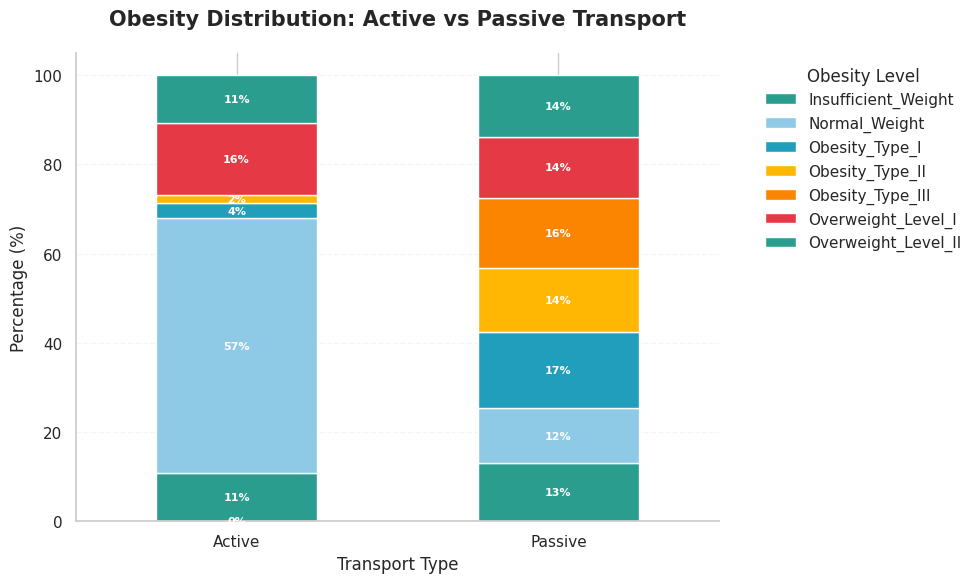

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 1. Create Active / Passive group =====
def transport_type(x):
    if x in ['Walking', 'Bicycle']:
        return 'Active'
    else:
        return 'Passive'

df['TransportGroup'] = df['MTRANS'].apply(transport_type)

# ===== 2. Crosstab + percentage =====
group = pd.crosstab(df['TransportGroup'], df['NObeyesdad'])
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# ===== 3. Style =====
sns.set_theme(style="whitegrid")

colors = [
    '#2a9d8f', '#8ecae6', '#219ebc',
    '#ffb703', '#fb8500', '#e63946'
]

fig, ax = plt.subplots(figsize=(10,6))

# ===== 4. Plot =====
group_pct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    width=0.5,
    ax=ax
)

# ===== 5. Title =====
ax.set_title('Obesity Distribution: Active vs Passive Transport',
             fontsize=15, weight='bold', pad=20)

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Transport Type')
ax.tick_params(axis='x', rotation=0)

# ===== 6. Clean style =====
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)

# ===== 7. Labels (clean + safe) =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f%%',
        label_type='center',
        fontsize=8,
        color='white',
        weight='bold'
    )

# ===== 8. Legend =====
ax.legend(title='Obesity Level',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Map transport to detailed activity (UPDATED) =====
def transport_detail(x):
    if x == 'Walking':
        return 'Walking'
    elif x == 'Bicycle':
        return 'Cycling'
    elif x == 'Motorbike':
        return 'Driving (Motorbike)'
    elif x == 'Automobile':
        return 'Driving (Car)'
    elif x == 'Public_Transportation':
        return 'Sitting (Public Transport)'
    else:
        return 'Inactive / Other'

df['TransportActivity'] = df['MTRANS'].apply(transport_detail)

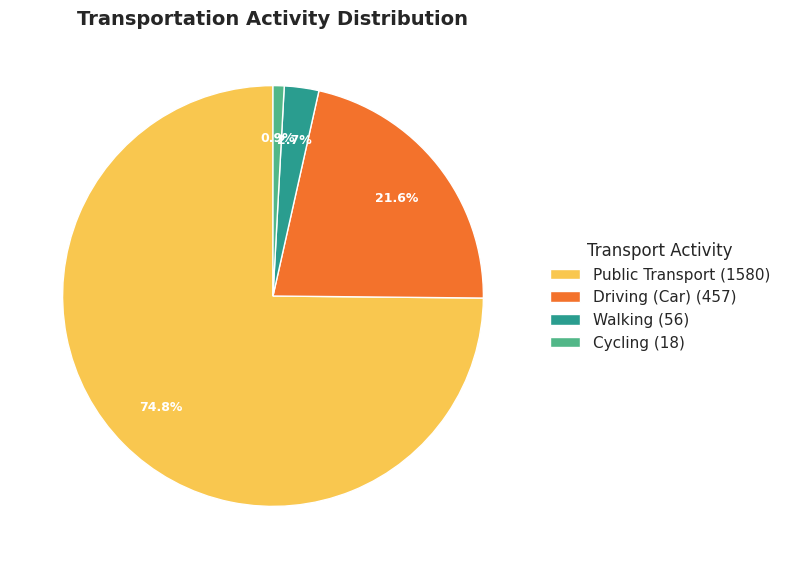

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Robust mapping =====
def transport_detail(x):
    x = str(x).lower()

    if 'walk' in x:
        return 'Walking'
    elif 'bike' in x:
        return 'Cycling'
    elif 'motor' in x:
        return 'Driving (Motorbike)'
    elif 'auto' in x or 'car' in x:
        return 'Driving (Car)'
    elif 'public' in x:
        return 'Public Transport'
    else:
        return 'Inactive / Other'

df['TransportActivity'] = df['MTRANS'].apply(transport_detail)

# ===== 2. Count =====
activity_counts = df['TransportActivity'].value_counts()

# ===== 3. Colors =====
color_map = {
    'Walking': '#2a9d8f',
    'Cycling': '#52b788',
    'Public Transport': '#f9c74f',
    'Driving (Motorbike)': '#f8961e',
    'Driving (Car)': '#f3722c',
    'Inactive / Other': '#e63946'
}

colors = [color_map.get(x, '#cccccc') for x in activity_counts.index]

# ===== 4. Plot =====
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    activity_counts,
    labels=None,              # ❌ ไม่ใส่ label ใน pie
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75
)

# ===== 5. Move labels OUTSIDE =====
plt.legend(
    wedges,
    [f'{k} ({v})' for k, v in activity_counts.items()],
    title="Transport Activity",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# ===== 6. Style text =====
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_weight('bold')

plt.title('Transportation Activity Distribution',
          fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

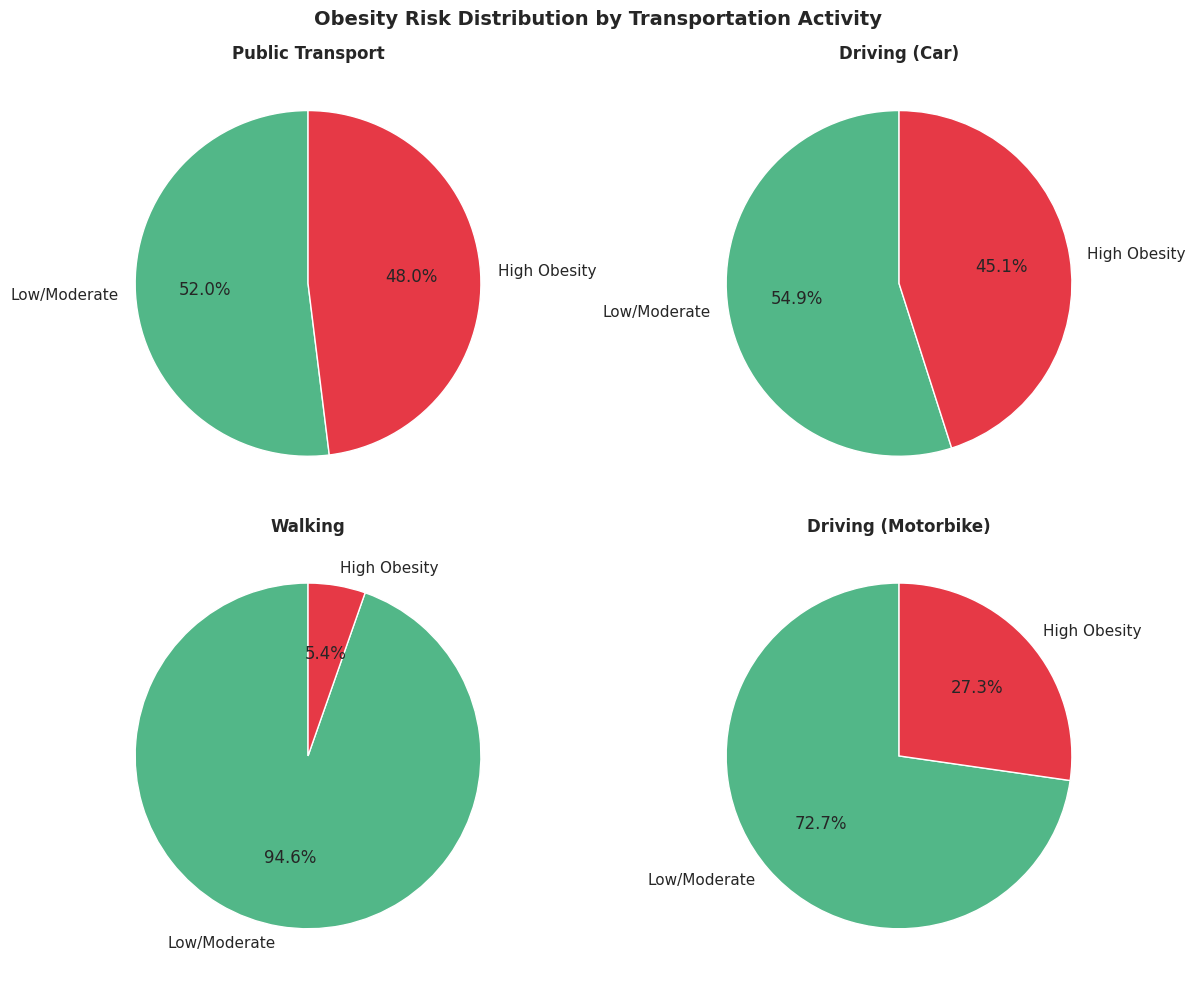

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Transport mapping (FIXED + more robust) =====
def transport_detail(x):
    if x == 'Walking':
        return 'Walking'
    elif x in ['Bicycle', 'Bike']:
        return 'Biking'
    elif x == 'Motorbike':
        return 'Driving (Motorbike)'
    elif x == 'Automobile':
        return 'Driving (Car)'
    elif x == 'Public_Transportation':
        return 'Public Transport'
    else:
        return 'Inactive / Other'

df['TransportActivity'] = df['MTRANS'].apply(transport_detail)

# ===== 2. Obesity grouping =====
def obesity_risk(x):
    high = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
    return 'High Obesity' if x in high else 'Low/Moderate'

df['ObesityRisk'] = df['NObeyesdad'].apply(obesity_risk)

# ===== 3. Activities (FIX: ensure all exist dynamically) =====
activities = df['TransportActivity'].value_counts().index.tolist()

colors = ['#52b788', '#e63946']  # Low, High

# ===== 4. Plot pies (FIXED LOOP SAFE) =====
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, act in enumerate(activities[:4]):  # 4 plots
    subset = df[df['TransportActivity'] == act]['ObesityRisk'].value_counts()

    axes[i].pie(
        subset,
        labels=subset.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )

    axes[i].set_title(act, fontsize=12, weight='bold')

# ===== 5. Hide unused subplots (IMPORTANT FIX) =====
for j in range(len(activities[:4]), 4):
    fig.delaxes(axes[j])

plt.suptitle('Obesity Risk Distribution by Transportation Activity',
             fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

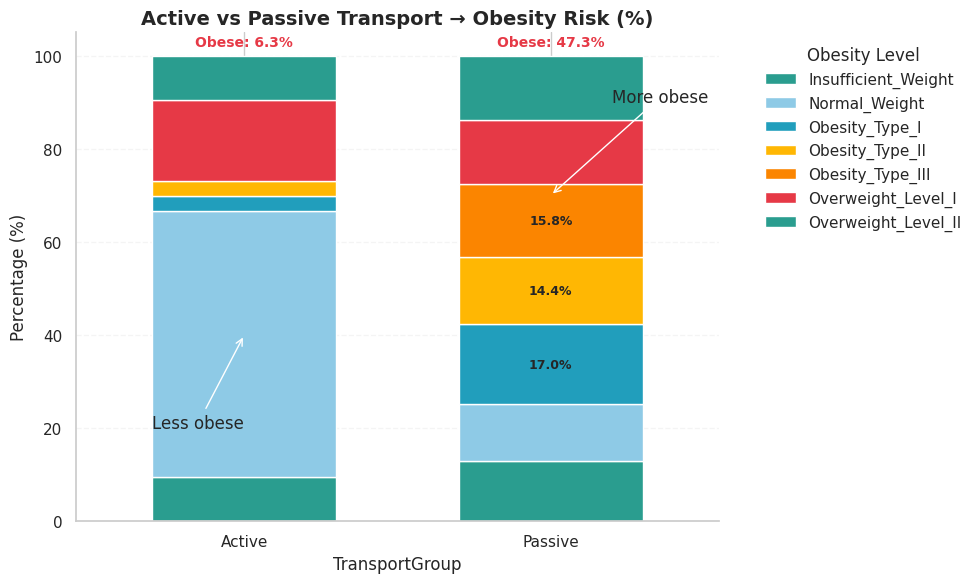

In [ ]:
import matplotlib.pyplot as plt

activity_colors = [
    '#2a9d8f', '#8ecae6', '#219ebc',
    '#ffb703', '#fb8500', '#e63946'
]

# create Active / Passive
def transport_type(x):
    return 'Active' if x in ['Walking', 'Bike'] else 'Passive'

df['TransportGroup'] = df['MTRANS'].apply(transport_type)

# group → %
group = df.groupby('TransportGroup')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# total obesity %
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

# sort by obesity
group_pct = group_pct.loc[total_obesity.sort_values().index]

# ===== plot =====
fig, ax = plt.subplots(figsize=(10,6))

group_pct.plot(
    kind='bar',
    stacked=True,
    color=activity_colors[:group_pct.shape[1]],  # 👈 FIX สีให้ตรง theme
    ax=ax,
    width=0.6
)

# ===== title =====
plt.title('Active vs Passive Transport → Obesity Risk (%)',
          fontsize=14, weight='bold')

plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# ===== label obesity segments =====
for i in range(len(group_pct)):
    cumulative = 0
    for col in group_pct.columns:
        value = group_pct.iloc[i][col]

        if col in obesity_cols and value > 5:
            ax.text(i, cumulative + value/2,
                    f"{value:.1f}%",
                    ha='center', va='center',
                    fontsize=9, weight='bold')

        cumulative += value

# ===== total obesity on top =====
for i, val in enumerate(total_obesity.sort_values()):
    ax.text(i, 102,
            f"Obese: {val:.1f}%",
            ha='center',
            fontsize=10,
            color='#e63946',   # 👈 match red tone from palette
            weight='bold')

# ===== annotations =====
plt.annotate("More obese",
             xy=(1, 70), xytext=(1.2, 90),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Less obese",
             xy=(0, 40), xytext=(-0.3, 20),
             arrowprops=dict(arrowstyle="->"))

# ===== legend =====
ax.legend(title='Obesity Level',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           frameon=False)

# ===== style clean =====
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

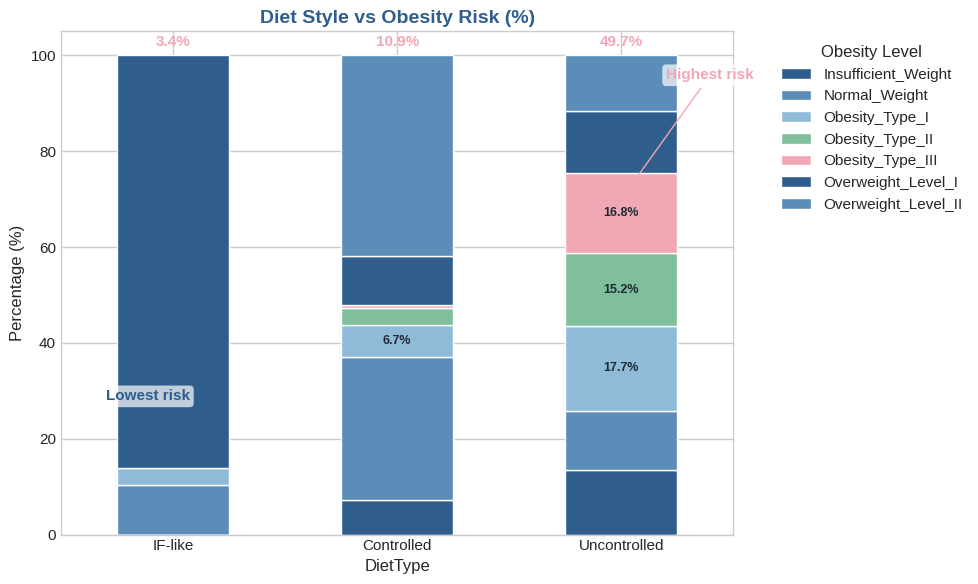

In [ ]:
import matplotlib.pyplot as plt

#define diet styles
def diet_type(row):
    if row['NCP'] <= 2 and row['CAEC'] == 'no':
        return 'IF-like'
    elif row['FAVC'] == 'no' and row['CAEC'] in ['Sometimes', 'no']:
        return 'Controlled'
    else:
        return 'Uncontrolled'

df['DietType'] = df.apply(diet_type, axis=1)

# 2. group as %
group = df.groupby('DietType')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# 3. total obesity (main insight)
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

#sort (low → high risk)
group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

# ===== 🇯🇵 ONLY COLOR CHANGED HERE =====
japan_fresh_colors = [
    "#2F5D8C",
    "#5B8DB8",
    "#8FBBD9",
    "#7FBF9B",
    "#F2A7B5"
]

ax = group_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=japan_fresh_colors
)

plt.title('Diet Style vs Obesity Risk (%)', fontsize=14, weight='bold', color="#2F5D8C")
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# highlight ONLY obesity
for i in range(len(group_pct)):
    cumulative = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(
                i,
                cumulative + val/2,
                f"{val:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                weight='bold',
                color="#1F2A36"
            )
        cumulative += val

for i, val in enumerate(total_obesity):
    ax.text(
        i, 102,
        f"{val:.1f}%",
        ha='center',
        fontsize=11,
        color="#F2A7B5",
        weight='bold'
    )

# ===== FIXED ANNOTATIONS =====
plt.annotate(
    "Lowest risk",
    xy=(0, 40),
    xytext=(-0.3, 28),   # 👈 fixed (no more overlap)
    arrowprops=dict(arrowstyle="->", color="#2F5D8C"),
    color="#2F5D8C",
    fontsize=11,
    weight='bold',
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7)
)

plt.annotate(
    "Highest risk",
    xy=(2, 70),
    xytext=(2.2, 95),
    arrowprops=dict(arrowstyle="->", color="#F2A7B5"),
    color="#F2A7B5",
    fontsize=11,
    weight='bold',
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7)
)

plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#Seasoning Behavior

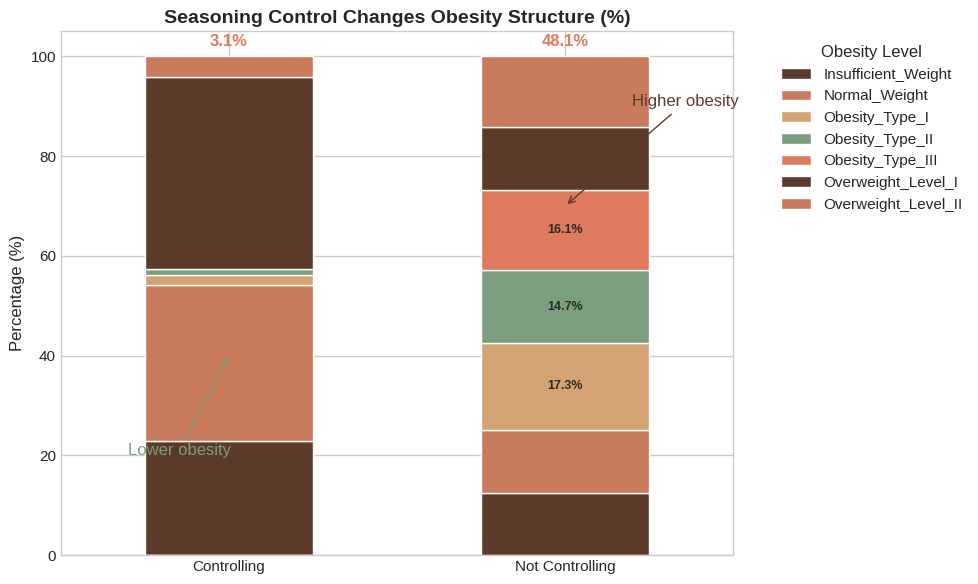

In [ ]:
import matplotlib.pyplot as plt

# group %
group = df.groupby('SCC')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

group_pct.index = ['Not Controlling', 'Controlling']

# total obesity (main insight)
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

# sort
group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

# ===== 🧂 seasoning palette =====
seasoning_palette = [
    "#5B3A29",  # soy sauce
    "#C97C5D",  # chili oil
    "#D4A373",  # mustard/sesame
    "#7A9E7E",  # herb green
    "#E07A5F"   # spicy accent
]

# plot (ONLY color changed)
ax = group_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=seasoning_palette
)

plt.title('Seasoning Control Changes Obesity Structure (%)', fontsize=14, weight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# highlight obesity
for i in range(len(group_pct)):
    cum = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(
                i, cum + val/2,
                f"{val:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                weight='bold',
                color="#2B2B2B"
            )
        cum += val

# big number = takeaway
for i, val in enumerate(total_obesity):
    ax.text(
        i, 102,
        f"{val:.1f}%",
        ha='center',
        fontsize=12,
        color="#E07A5F",
        weight='bold'
    )

# storytelling arrows
plt.annotate(
    "Higher obesity",
    xy=(1, 70), xytext=(1.2, 90),
    arrowprops=dict(arrowstyle="->", color="#5B3A29"),
    color="#5B3A29"
)

plt.annotate(
    "Lower obesity",
    xy=(0, 40), xytext=(-0.3, 20),
    arrowprops=dict(arrowstyle="->", color="#7A9E7E"),
    color="#7A9E7E"
)

plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [ ]:
def taste_type(row):
    if row['FAVC'] == 'yes' and row['CAEC'] == 'Frequently':
        return 'Sweet/High-calorie'
    elif row['CAEC'] == 'Sometimes':
        return 'Salty/Processed'
    elif row['NCP'] <= 2:
        return 'Sour/Light pattern'
    else:
        return 'Spicy/Irregular'

In [ ]:
df['TasteType'] = df.apply(taste_type, axis=1)

In [ ]:
group = df.groupby('TasteType')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

In [ ]:
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
risk_score = group_pct[obesity_cols].sum(axis=1).sort_values(ascending=False)

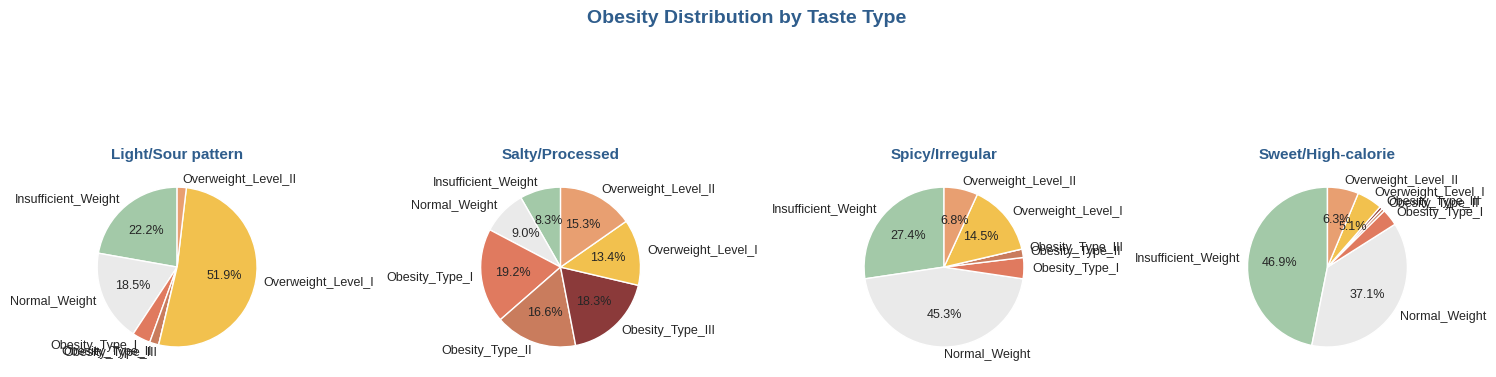

In [ ]:
import matplotlib.pyplot as plt

# ===== taste grouping =====
def taste_type(row):
    if row['FAVC'] == 'yes' and row['CAEC'] == 'Frequently':
        return 'Sweet/High-calorie'
    elif row['CAEC'] == 'Sometimes':
        return 'Salty/Processed'
    elif row['NCP'] <= 2:
        return 'Light/Sour pattern'
    else:
        return 'Spicy/Irregular'

df['TasteType'] = df.apply(taste_type, axis=1)

# ===== group % =====
group = df.groupby('TasteType')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100
group_pct = group_pct.fillna(0)

# ===== 🎯 ใช้ทุก obesity level =====
all_levels = group_pct.columns.tolist()

# ===== 🎨 color palette (ครบทุกระดับ) =====
colors = {
    "Insufficient_Weight": "#A3C9A8",
    "Normal_Weight": "#EAEAEA",
    "Overweight_Level_I": "#F2C14E",
    "Overweight_Level_II": "#E89F71",
    "Obesity_Type_I": "#E07A5F",
    "Obesity_Type_II": "#C97C5D",
    "Obesity_Type_III": "#8B3A3A"
}

# fallback color (กรณีมี class ใหม่)
default_color = "#D3D3D3"

# ===== plot =====
fig, axes = plt.subplots(1, len(group_pct), figsize=(15, 5))

if len(group_pct) == 1:
    axes = [axes]

for i, (taste, row) in enumerate(group_pct.iterrows()):
    values = []
    labels = []
    pie_colors = []

    for col in all_levels:
        val = row[col]
        values.append(val)
        labels.append(col)
        pie_colors.append(colors.get(col, default_color))

    axes[i].pie(
        values,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%' if p > 5 else '',
        startangle=90,
        colors=pie_colors,
        textprops={'fontsize': 9}
    )

    axes[i].set_title(taste, fontsize=11, weight='bold', color="#2F5D8C")

plt.suptitle("Obesity Distribution by Taste Type", fontsize=14, weight='bold', color="#2F5D8C")
plt.tight_layout()
plt.show()

#Water Intake Grouping
🟥 Low intake: < 1,000 ml / day

🟧 Below recommended: 1,000 – 1,999 ml

🟩 Adequate: 2,000 – 2,999 ml

🟦 High intake: ≥ 3,000 ml

In [ ]:
import pandas as pd

# group water intake (เหมือนเดิม)
bins = [0, 1000, 2000, 3000, float('inf')]
labels = ['Low (<1L)', 'Below rec (1–2L)', 'Adequate (2–3L)', 'High (>3L)']

df['WaterType'] = pd.cut(df['CH2O'], bins=bins, labels=labels)

# pivot table
table = pd.crosstab(df['WaterType'], df['NObeyesdad'])

# add row total
table['Total'] = table.sum(axis=1)

# add percentage (row-wise)
table_pct = table.iloc[:, :-1].div(table['Total'], axis=0) * 100

print("=== Count Table ===")
print(table)

print("\n=== Percentage Table ===")
print(table_pct.round(2))

=== Count Table ===
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
WaterType                                                        
Low (<1L)                   272            287             351   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
WaterType                                                           
Low (<1L)               297               324                 290   

NObeyesdad  Overweight_Level_II  Total  
WaterType                               
Low (<1L)                   290   2111  

=== Percentage Table ===
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
WaterType                                                        
Low (<1L)                 12.88           13.6           16.63   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
WaterType                                                           
Low (<1L)             14.07             15.35               13.74   

NObeyesdad  Overw

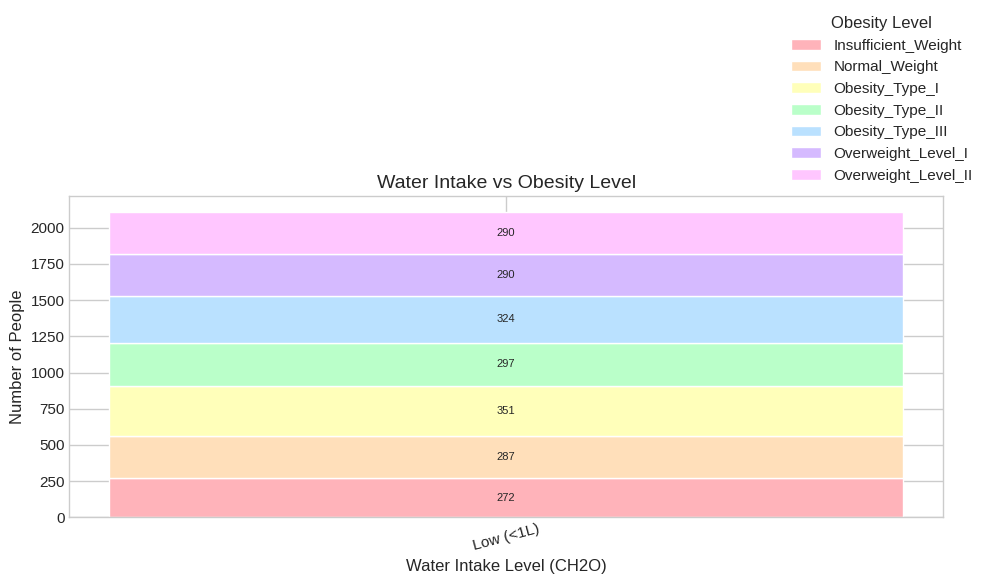

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== Group Water Intake =====
bins = [0, 1000, 2000, 3000, float('inf')]
labels = ['Low (<1L)', 'Below rec (1–2L)', 'Adequate (2–3L)', 'High (>3L)']

df['WaterType'] = pd.cut(df['CH2O'], bins=bins, labels=labels)

# ===== Crosstab =====
cross = pd.crosstab(df['WaterType'], df['NObeyesdad']).reindex(labels)

# ===== FIX COLOR MAP=====
obesity_levels = cross.columns.tolist()

color_palette = [
    "#ffb3ba",  # soft pink
    "#ffdfba",  # peach
    "#ffffba",  # soft yellow
    "#baffc9",  # mint
    "#bae1ff",  # baby blue
    "#d5baff",  # lavender
    "#ffc6ff",  # pastel purple-pink
    "#caffbf"   # light green
]

colors = {level: color_palette[i % len(color_palette)] for i, level in enumerate(obesity_levels)}

# =====  Plot =====
plt.figure(figsize=(10,6))

bottom = pd.Series([0]*len(cross), index=cross.index)

for col in cross.columns:
    bars = plt.bar(
        cross.index,
        cross[col],
        bottom=bottom,
        color=colors[col],
        label=col
    )

    # annotation
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{int(height)}',
                ha='center',
                va='center',
                fontsize=8
            )

    bottom += cross[col]

# ===== tyling =====
plt.title('Water Intake vs Obesity Level', fontsize=14)
plt.xlabel('Water Intake Level (CH2O)')
plt.ylabel('Number of People')
plt.xticks(rotation=15)
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

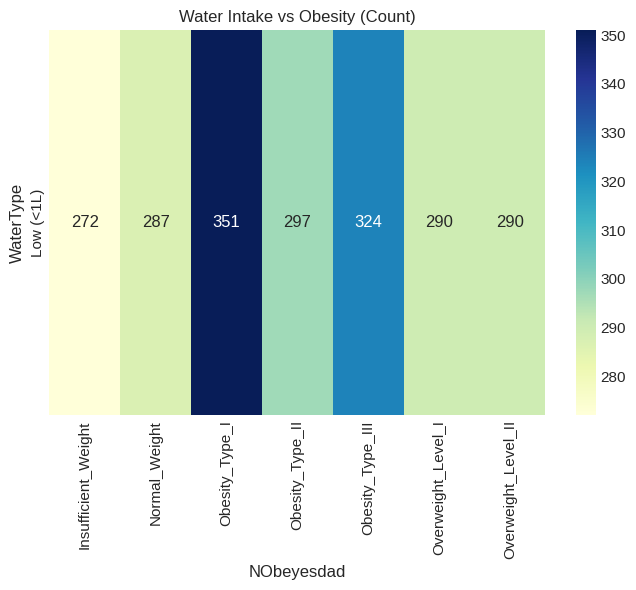

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(table.iloc[:,:-1], annot=True, fmt='d', cmap='YlGnBu')
plt.title("Water Intake vs Obesity (Count)")
plt.show()

In [ ]:
import pandas as pd

# ===== group water intake =====
bins = [0, 1000, 2000, 3000, float('inf')]
labels = ['Low (<1L)', 'Below rec (1–2L)', 'Adequate (2–3L)', 'High (>3L)']

df['WaterType'] = pd.cut(df['CH2O'], bins=bins, labels=labels)

# ===== cross tab =====
cross = pd.crosstab(df['WaterType'], df['NObeyesdad']).reindex(labels)

# ===== convert to percentage =====
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

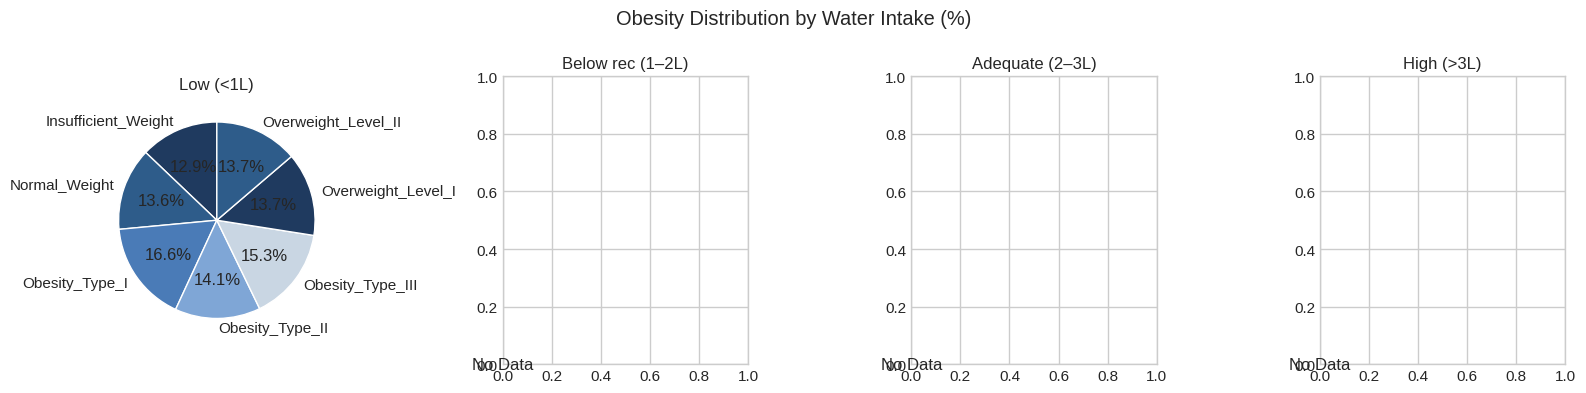

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(cross_pct.index), figsize=(16,4))

# Ensure axes is always an array, even for a single subplot
if len(cross_pct.index) == 1:
    axes = [axes]

for i, water in enumerate(cross_pct.index):
    # Fill NaN values with 0 before passing to pie chart
    data_for_pie = cross_pct.loc[water].fillna(0)

    # Filter out labels for segments that are 0 to avoid clutter
    labels_filtered = [label for label, value in data_for_pie.items() if value > 0]
    data_filtered = [value for value in data_for_pie if value > 0]

    if len(data_filtered) > 0: # Only plot if there is actual data
        axes[i].pie(
            data_filtered,
            labels=labels_filtered,
            autopct='%1.1f%%',
            startangle=90
        )
    else:
        # If no data, display a message or leave blank
        axes[i].text(0, 0, 'No Data', horizontalalignment='center', verticalalignment='center', fontsize=12)

    axes[i].set_title(water)

plt.suptitle('Obesity Distribution by Water Intake (%)')
plt.tight_layout()
plt.show()

#Screen times x Activity

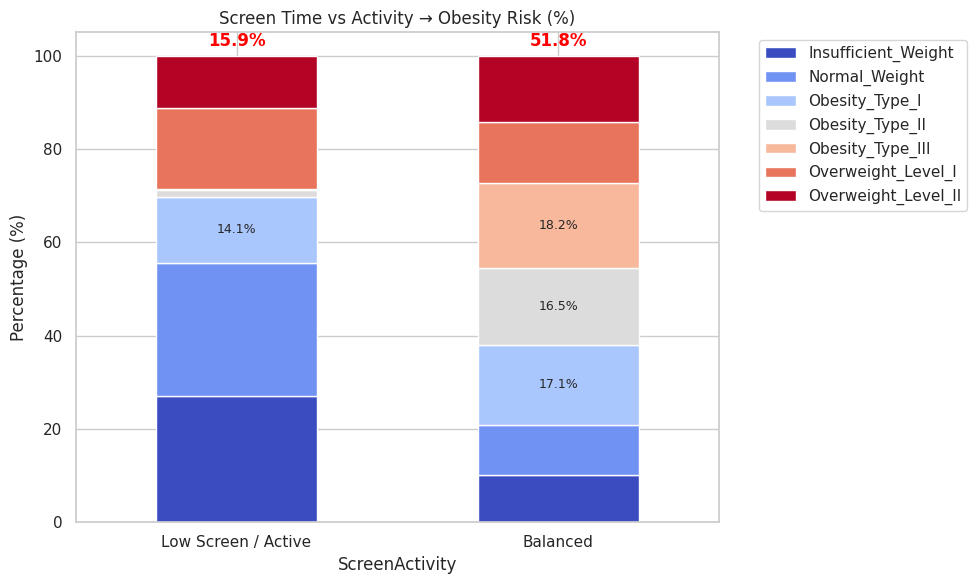

In [ ]:
def screen_activity(row):
    if row['TUE'] > 3 and row['FAF'] < 1:
        return 'High Screen / Low Activity'
    elif row['TUE'] < 2 and row['FAF'] >= 2:
        return 'Low Screen / Active'
    else:
        return 'Balanced'

df['ScreenActivity'] = df.apply(screen_activity, axis=1)

group = df.groupby('ScreenActivity')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

ax = group_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')

plt.title('Screen Time vs Activity → Obesity Risk (%)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

for i in range(len(group_pct)):
    cum = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(i, cum + val/2, f"{val:.1f}%", ha='center', va='center', fontsize=9)
        cum += val

for i, val in enumerate(total_obesity):
    ax.text(i, 102, f"{val:.1f}%", ha='center', color='red', weight='bold')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

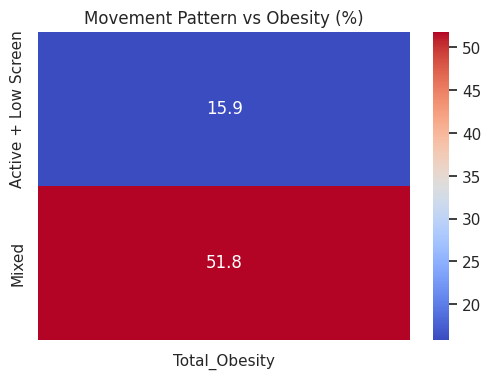

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def movement_type(row):
    if row['FAF'] >= 2 and row['TUE'] < 2:
        return 'Active + Low Screen'
    elif row['FAF'] < 1 and row['TUE'] > 3:
        return 'Inactive + High Screen'
    else:
        return 'Mixed'

df['MovementType'] = df.apply(movement_type, axis=1)

# คำนวณ % obesity ต่อกลุ่ม
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

group = df.groupby('MovementType')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# เอาเฉพาะ obesity รวม
group_pct['Total_Obesity'] = group_pct[obesity_cols].sum(axis=1)

# reshape สำหรับ heatmap
heatmap_data = group_pct[['Total_Obesity']]

# plot
plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")

plt.title('Movement Pattern vs Obesity (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

#Family genetics x Lifestyle

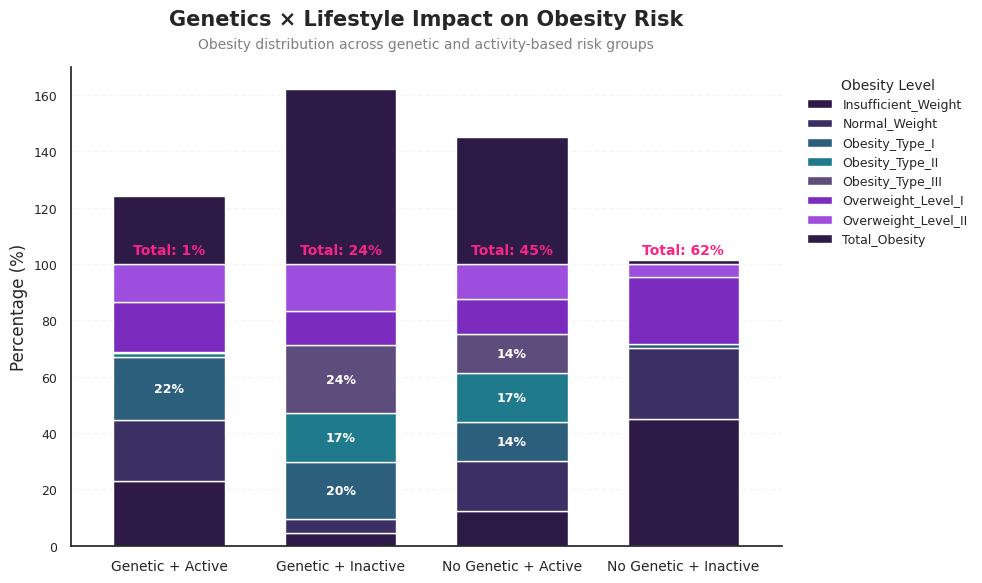

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10,6))

group_pct.plot(kind='bar',
                stacked=True,
                color=genetic_colors,
                width=0.65,
                ax=ax)

# ===== Title =====
ax.set_title('Genetics × Lifestyle Impact on Obesity Risk',
             fontsize=15, weight='bold', pad=30)

ax.text(0.5, 1.04,
        'Obesity distribution across genetic and activity-based risk groups',
        transform=ax.transAxes,
        ha='center',
        fontsize=10,
        color='gray')

# ===== Axis cleanup =====
ax.set_xlabel('')
ax.set_ylabel('Percentage (%)')

ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=9)

ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.15)

# ===== STACK LABELS (เพิ่ม spacing ตรงนี้) =====
for i in range(len(group_pct)):
    cum = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]

        if col in obesity_cols and val > 8:
            ax.text(
                i,
                cum + (val/2),   # center ของ bar
                f'{val:.0f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                weight='bold'
            )
        cum += val

# ===== TOTAL (ขยับให้ลอยขึ้นอีก) =====
for i, val in enumerate(total_obesity):
    ax.text(
        i,
        103.5,  # 👈 ขยับขึ้นจาก 101.5 → 103.5
        f'Total: {val:.0f}%',
        ha='center',
        fontsize=10,
        color='#f72585',
        weight='bold'
    )

# ===== Legend =====
ax.legend(title='Obesity Level',
          bbox_to_anchor=(1.02, 1),
          loc='upper left',
          frameon=False,
          fontsize=9,
          title_fontsize=10)

plt.tight_layout()
plt.show()

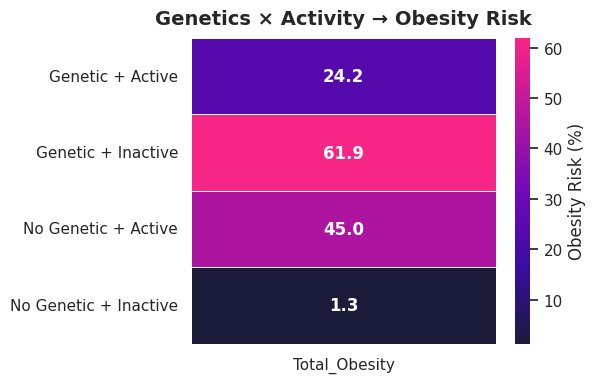

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

plt.figure(figsize=(6,4))

# ===== Beautiful smooth gradient =====
cmap = sns.blend_palette(
    ["#1b1b3a",  # deep navy (low risk)
     "#3a0ca3",  # deep purple
     "#7209b7",  # violet
     "#b5179e",  # pink
     "#f72585"], # hot pink (high risk)
    as_cmap=True
)

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Obesity Risk (%)'}
)

# ===== Title =====
plt.title('Genetics × Activity → Obesity Risk',
          fontsize=14, weight='bold', pad=10)

plt.ylabel('')
plt.xlabel('')

# ===== Clean annotation =====
for text in ax.texts:
    text.set_color("white")
    text.set_weight("bold")

plt.tight_layout()
plt.show()

#Genz risk behaviors cause obesity

In [ ]:
df_genz = df[df['Age'] <= 25].copy()
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,CALC,MTRANS,NObeyesdad,AgeGroup,VegGroup,TransportGroup,DietType,ScreenActivity,MovementType,RiskGroup
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,...,no,Public_Transportation,Normal_Weight,Young Adult,Medium Veg,Passive,Controlled,Balanced,Mixed,Genetic + Inactive
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,...,Sometimes,Public_Transportation,Normal_Weight,Young Adult,High Veg,Passive,Controlled,Low Screen / Active,Active + Low Screen,Genetic + Active
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,...,Frequently,Public_Transportation,Normal_Weight,Young Adult,Medium Veg,Passive,Controlled,Low Screen / Active,Active + Low Screen,Genetic + Active
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,...,Frequently,Walking,Overweight_Level_I,Adult,High Veg,Active,Controlled,Low Screen / Active,Active + Low Screen,No Genetic + Active
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,...,Sometimes,Public_Transportation,Overweight_Level_II,Young Adult,Medium Veg,Passive,Controlled,Balanced,Mixed,No Genetic + Inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,...,Sometimes,Public_Transportation,Obesity_Type_III,Young Adult,High Veg,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,...,Sometimes,Public_Transportation,Obesity_Type_III,Young Adult,High Veg,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,...,Sometimes,Public_Transportation,Obesity_Type_III,Young Adult,High Veg,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,...,Sometimes,Public_Transportation,Obesity_Type_III,Young Adult,High Veg,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active


In [ ]:
df_genz['High_Alcohol'] = df_genz['CALC'].isin(['Frequently', 'Always'])
df_genz['Low_Water'] = df_genz['CH2O'] < 2
df_genz['Snacking'] = df_genz['CAEC'].isin(['Frequently', 'Always'])
df_genz['Inactive'] = df_genz['FAF'] < 1
df_genz['High_Screen'] = df_genz['TUE'] > 3

In [ ]:
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

results = {}

for col in ['High_Alcohol', 'Low_Water', 'Snacking', 'Inactive', 'High_Screen']:
    grp = df_genz.groupby(col)['NObeyesdad'].value_counts().unstack()
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    grp_pct['Total_Obesity'] = grp_pct[obesity_cols].sum(axis=1)

    # Only add to results if the 'True' category (risky behavior) exists in the index
    if True in grp_pct.index:
        results[col] = grp_pct.loc[True, 'Total_Obesity']

import pandas as pd
risk_df = pd.DataFrame.from_dict(results, orient='index', columns=['Obesity_%'])
risk_df = risk_df.sort_values(by='Obesity_%')

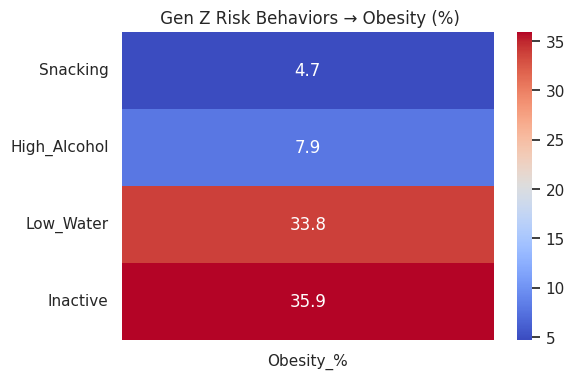

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(risk_df, annot=True, fmt=".1f", cmap="coolwarm")

plt.title(' Gen Z Risk Behaviors → Obesity (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()